<a href="https://colab.research.google.com/github/syenirasheila/Detection-of-Rice-Leaf-Disease-in-Indonesia-InceptionV3/blob/main/Final_Detection_Rice_Leaf_Disease_Indonesia_InceptionV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PENGUMPULAN DATA

In [1]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU

In [2]:
IMG_SIZE = (299, 299)
directory = "../data/Penyakit_Daun_Padi_Indonesia"
BATCH_SIZE = 8

train_dataset = image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 240 files belonging to 3 classes.
Using 192 files for training.
Found 240 files belonging to 3 classes.
Using 48 files for validation.


In [3]:
class_names = train_dataset.class_names
class_names

['blast', 'blight', 'tungro']

In [4]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

C:\Users\bacht\AppData\Local\Temp\ipykernel_15048\4125836417.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Blast", "Blight", "Tungro"], y=Data_imbalance, palette="rocket")


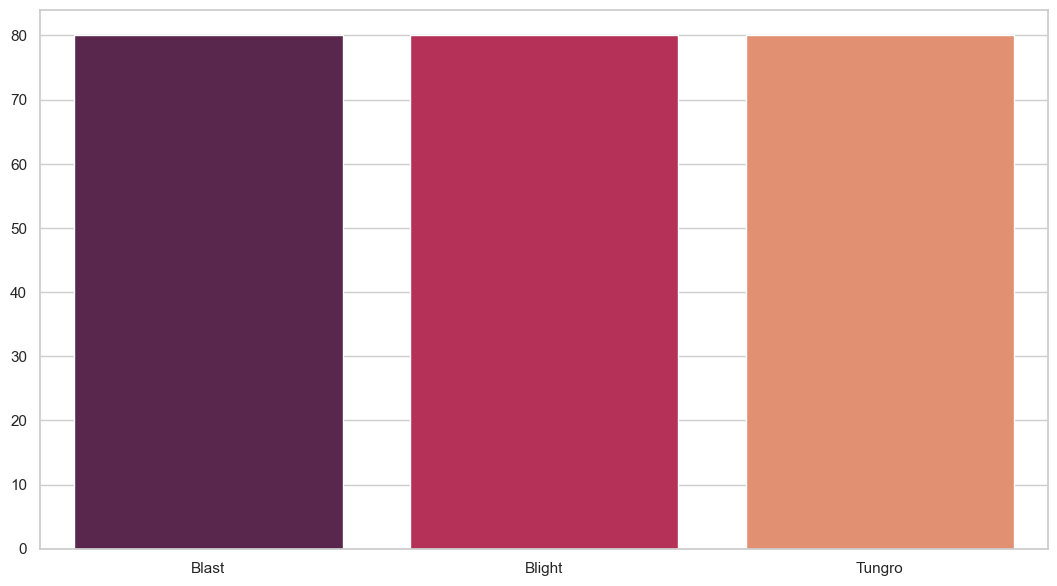

In [5]:
#eksplorasi dataset
sns.set_theme(style="whitegrid")
Data_imbalance = []
for folder in os.listdir(directory):
    files = gb.glob(pathname=str(directory + "/" + folder +"/*.*"))
    Data_imbalance.append(len(files))
plt.figure(figsize=(13,7))
sns.barplot(x=["Blast", "Blight", "Tungro"], y=Data_imbalance, palette="rocket")
plt.show()

In [6]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))

Weight for class 0: 0.75
Weight for class 1: 0.75
Weight for class 2: 0.75


# PRE-PROCESSING

In [7]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])


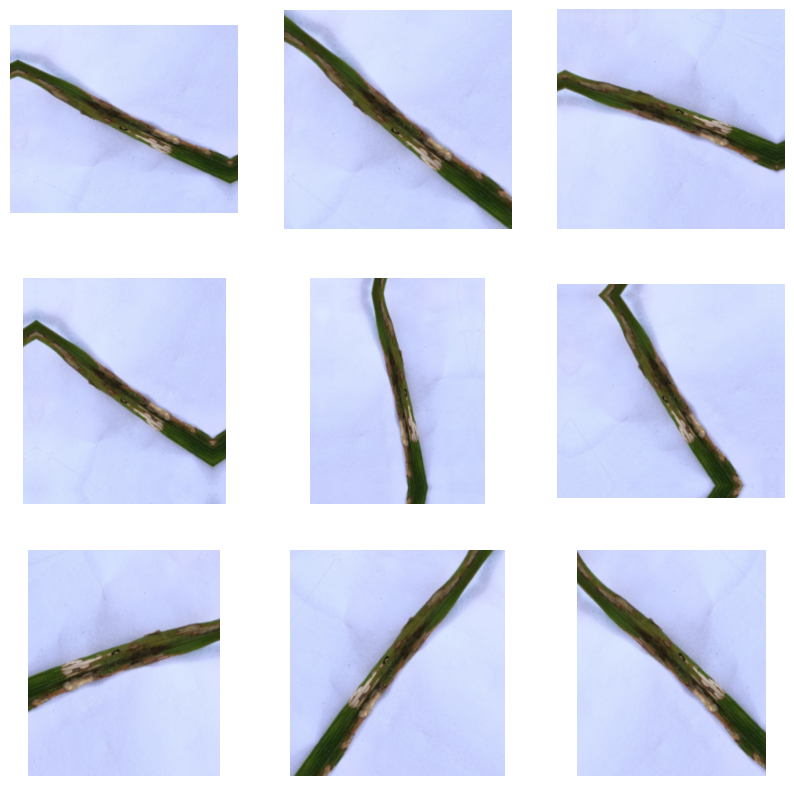

In [8]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

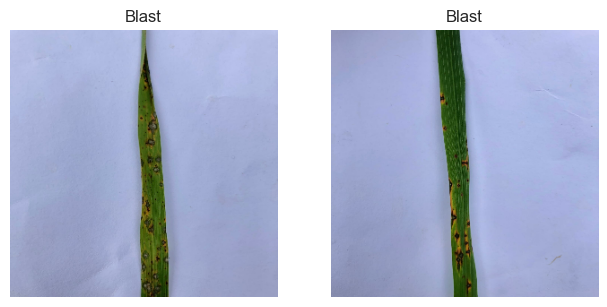

In [9]:
Blast = []
Blight = []
Tungro = []

for images, labels in train_dataset.take(1):
    for i in range(len(images)):
        if class_names[labels[i]] == "blast":
            Blast.append(images[i].numpy().astype("uint8"))
        elif class_names[labels[i]] == "blight":
            Blight.append(images[i].numpy().astype("uint8"))
        elif class_names[labels[i]] == "tungro":
            Tungro.append(images[i].numpy().astype("uint8"))

plt.figure(figsize=(20,8))
for i in range(min(10, len(Blast))):
    plt.subplot(2,5,i+1)
    plt.imshow(Blast[i])
    plt.axis("off")
    plt.title("Blast")

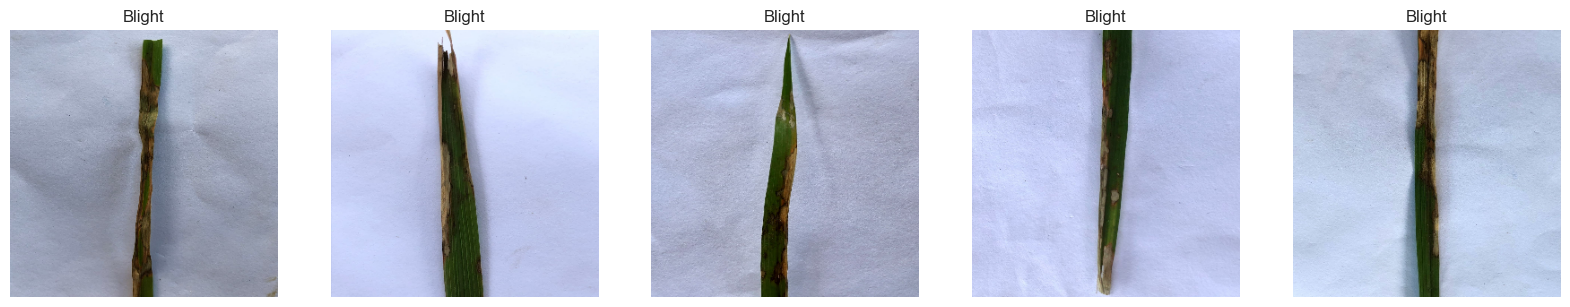

In [26]:
plt.figure(figsize=(20,8))

for i in range(min(10, len(Blight))):
    plt.subplot(2,5,i+1)
    plt.imshow(Blight[i])
    plt.axis("off")
    plt.title("Blight")

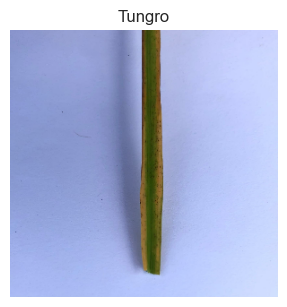

In [11]:
plt.figure(figsize=(20,8))

for i in range(min(10, len(Tungro))):
    plt.subplot(2,5,i+1)
    plt.imshow(Tungro[i])
    plt.axis("off")
    plt.title("Tungro")

In [12]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

# METODE KLASIFIKASI CNN


In [13]:
IMG_SHAPE = IMG_SIZE +(3,)
base_model = tf.keras.applications.InceptionV3(input_shape=IMG_SHAPE, include_top= False,weights='imagenet')

In [14]:
type(base_model)
preprocess_input = tf.keras.applications.inception_v3.preprocess_input

In [15]:
nb_layers = len(base_model.layers)
print("Numbers of Layers =" , nb_layers)
print(base_model.layers[nb_layers - 2].name)
print(base_model.layers[nb_layers - 1].name)

Numbers of Layers = 311
activation_93
mixed10


In [16]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(8, 8, 8, 2048)


In [17]:
def model_penyakit_daun_padi( image_shape=IMG_SIZE):
    '''tf.keras model for multi-class classification out of the InceptionV3 model '''
    image_shape = image_shape + (3,)

    resnet_model = tf.keras.applications.InceptionV3(input_shape=IMG_SHAPE, include_top= False,weights='imagenet')
    resnet_model.trainable = True
    for layer in resnet_model.layers[0 : 291]:
        layer.trainable = False

    inputs = tf.keras.Input(image_shape)
    x = data_augmentation(inputs)
    x = preprocess_input(inputs)
    x = resnet_model(x , training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    prediction_layer = tf.keras.layers.Dense(4 ,activation = "softmax")
    outputs = prediction_layer(x)
    model = tf.keras.Model(inputs, outputs)
    model.summary()
    return model

In [18]:
Model_Penyakit_Daun_Padi = model_penyakit_daun_padi(IMG_SIZE)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 1,943,556 (7.41 MB)

 Non-trainable params: 19,867,424 (75.79 MB)

In [19]:
import tensorflow as tf
model_viz = tf.keras.utils.plot_model(Model_Penyakit_Daun_Padi,
                          to_file='xception.png',
                          show_shapes=True,
                          show_layer_names=True,
                          rankdir='TB',
                          expand_nested=True,
                          dpi=55)
model_viz

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [20]:
base_learning_rate = 0.001
Model_Penyakit_Daun_Padi.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=base_learning_rate),
                           loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                           metrics=['accuracy'])

In [21]:
history = Model_Penyakit_Daun_Padi.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    verbose=2
)

Epoch 1/10
24/24 - 67s - 3s/step - accuracy: 0.8073 - loss: 0.4471 - val_accuracy: 0.7292 - val_loss: 0.9201
Epoch 2/10
24/24 - 38s - 2s/step - accuracy: 0.9740 - loss: 0.1040 - val_accuracy: 0.8125 - val_loss: 0.7573
Epoch 3/10
24/24 - 43s - 2s/step - accuracy: 0.9896 - loss: 0.0389 - val_accuracy: 0.8958 - val_loss: 0.5845
Epoch 4/10
24/24 - 49s - 2s/step - accuracy: 0.9896 - loss: 0.0574 - val_accuracy: 0.9375 - val_loss: 0.4332
Epoch 5/10
24/24 - 33s - 1s/step - accuracy: 1.0000 - loss: 0.0279 - val_accuracy: 0.9375 - val_loss: 0.2627
Epoch 6/10
24/24 - 32s - 1s/step - accuracy: 0.9844 - loss: 0.0422 - val_accuracy: 0.9167 - val_loss: 0.3540
Epoch 7/10
24/24 - 32s - 1s/step - accuracy: 0.9948 - loss: 0.0402 - val_accuracy: 0.8333 - val_loss: 0.5529
Epoch 8/10
24/24 - 26s - 1s/step - accuracy: 0.9844 - loss: 0.0482 - val_accuracy: 0.9167 - val_loss: 0.2584
Epoch 9/10
24/24 - 25s - 1s/step - accuracy: 0.9844 - loss: 0.0473 - val_accuracy: 0.9167 - val_loss: 0.2964
Epoch 10/10
24/24 -

In [22]:
#melihat nilai acc dan loss
Model_Penyakit_Daun_Padi.evaluate(validation_dataset , verbose = 1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9583 - loss: 0.2699


[0.2698933780193329, 0.9583333134651184]

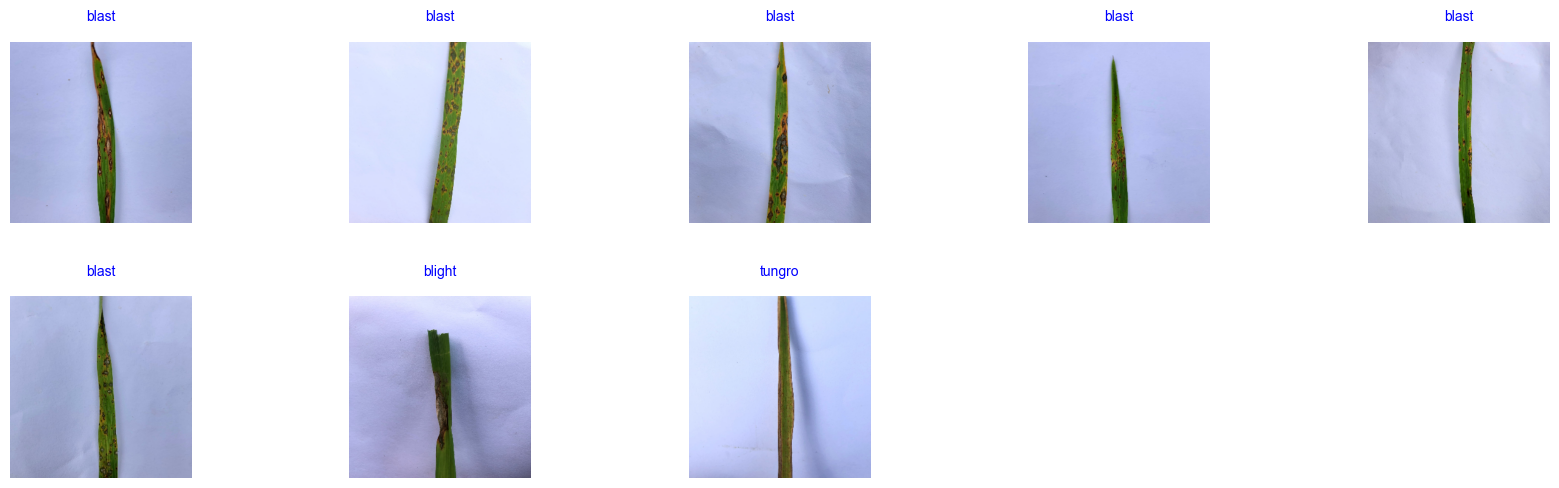

In [23]:
plt.figure(figsize=(20, 15))

for images, labels in train_dataset.take(1):

    for i in range(min(25, len(images))):
        plt.subplot(5, 5, i+1)

        img = images[i].numpy().astype("uint8")
        plt.imshow(img)
        plt.axis("off")

        img_input = tf.expand_dims(img, 0)
        predict = Model_Penyakit_Daun_Padi.predict(img_input, verbose=0)

        predicted = class_names[np.argmax(predict)]
        actual = class_names[labels[i].numpy()]

        if actual == predicted:
            plt.title(predicted, fontsize=10, color="blue", pad=15)
        else:
            plt.title(actual, fontsize=10, color="red", pad=15)

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9,
                    top=0.9, wspace=0.4, hspace=0.4)
plt.show()

# EVALUASI MODEL

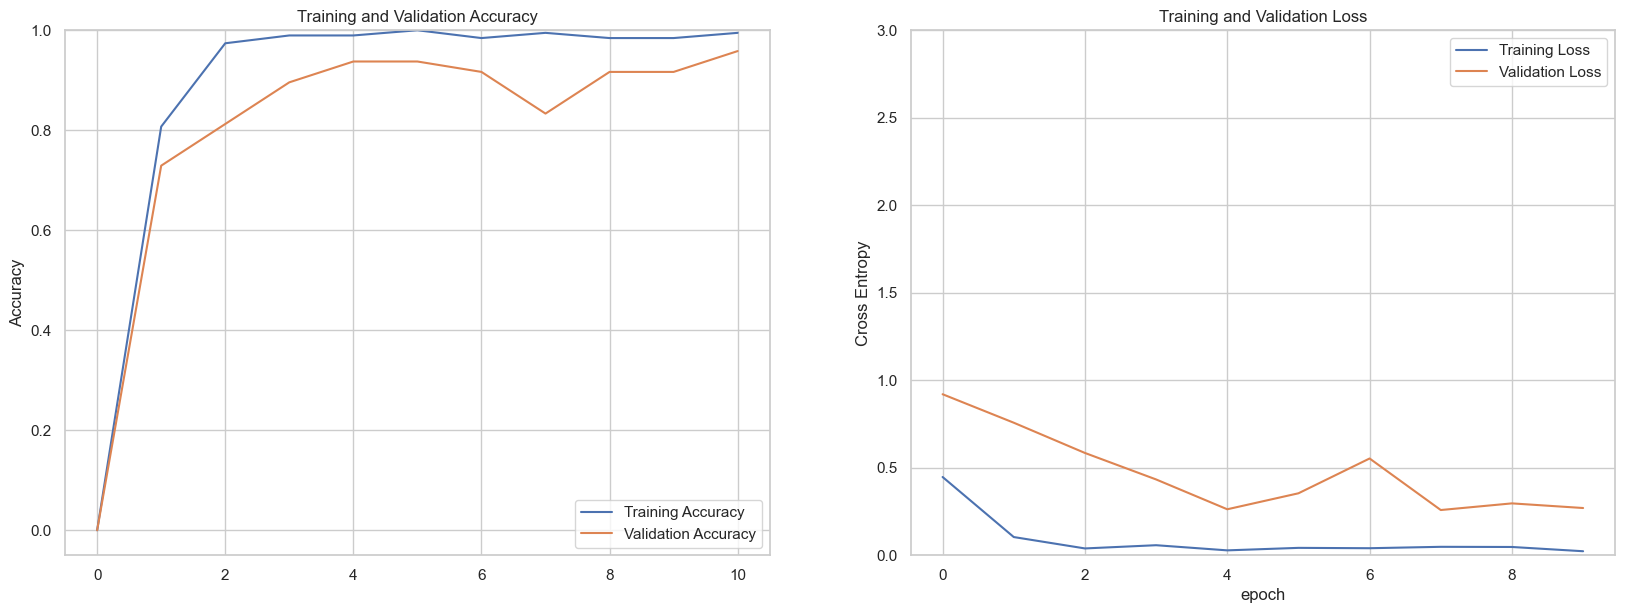

In [24]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

#plot MSE
plt.figure(figsize=(20, 15))
plt.subplot(2, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

#plot MAE
plt.subplot(2, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,3.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [25]:
import os

os.makedirs("../model", exist_ok=True)

Model_Penyakit_Daun_Padi.save("../model/rice_leaf_model.keras")

print("Model berhasil disimpan!")

Model berhasil disimpan!
